=== Ejercicio 0a: Exploración rápida ===
Filas: 270   Columnas: 172
Rango: 2021-03-28 a 2026-05-31
Valores nulos totales: 0

=== Ejercicio 0b: Rango de cada variable base (detección de outliers) ===
temp           min=     25.16  max=     32.63  std=    1.47
temp_max       min=     27.55  max=     38.98  std=    2.63
temp_min       min=     21.87  max=     27.69  std=    0.85
hum_esp        min=     14.97  max=     21.15  std=    1.37
hum_rel        min=     55.72  max=     94.15  std=    9.72
prec           min=      0.00  max=    160.56  std=   28.17
dias_lluvia    min=      0.00  max=      7.00  std=    2.25
vel_vi         min=      0.10  max=      0.37  std=    0.03
vel_vi_max     min=      0.19  max=      0.61  std=    0.08
vel_vi_min     min=      0.01  max=      0.14  std=    0.01
soi            min=  -2659.43  max=   2190.71  std=  390.45
sst            min=     -1.06  max=      2.34  std=    0.84

>>> Nota cómo 'soi' tiene una desviación estándar (std) muchísimo más
>>> grande

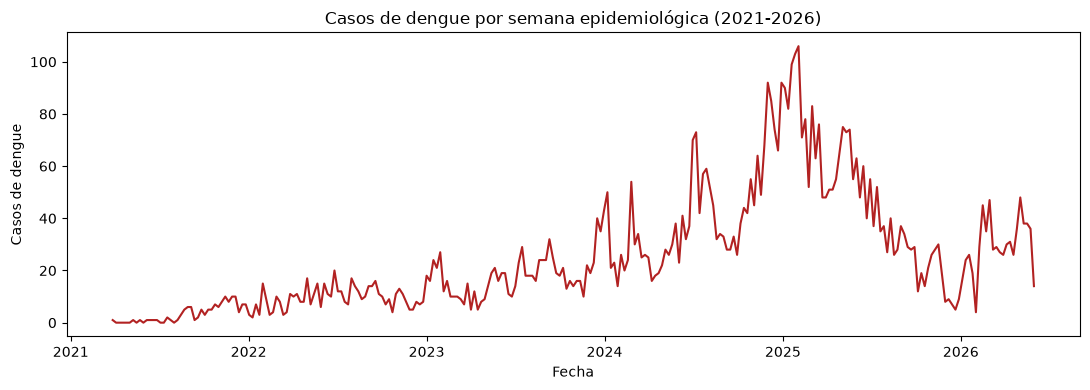

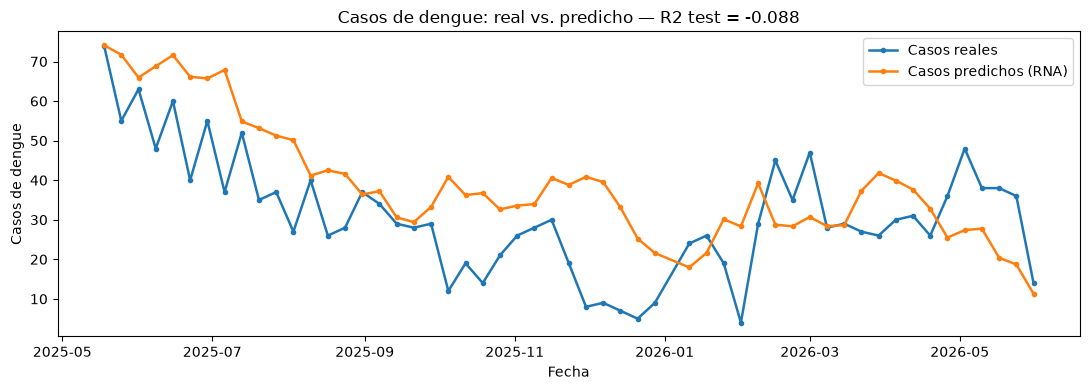

In [3]:
"""
PRACTICA: Redes Neuronales Artificiales aplicadas a la predicción de
casos de dengue - Datos reales 2021 a 2026 (semana 1)
=====================================================================

Dataset: 2_meteo_epi_2021-2026_1_rezagos.xlsx
270 semanas epidemiológicas, del 2021-03-28 al 2026-05-31.

IMPORTANTE - HALLAZGO DE CALIDAD DE DATOS (léelo antes de seguir):
Al explorar el archivo se detectó que la variable `soi` (y por lo
tanto todos sus rezagos `soi_lag_1`...`soi_lag_12`) tiene valores
completamente fuera de rango desde 2026-01-11 en adelante. El SOI
real se mueve típicamente entre -40 y +35 en este dataset, pero en
esas semanas llega hasta -2659 o +2190. Esto casi con toda seguridad
es un error de carga/transcripción en la fuente original (posible
error de unidades o una fórmula que se rompió en esa parte de la
hoja de cálculo), no un valor climático real.

Si entrenas un modelo con esos valores tal cual, las predicciones se
disparan a números absurdos (varios cientos de casos) porque el MLP
extrapola de forma inestable ante entradas tan extremas. Este es un
ejemplo real y valioso de por qué SIEMPRE se debe hacer una revisión
de calidad de datos (EDA) antes de entrenar cualquier red neuronal:
"garbage in, garbage out" aplica también a las RNA, por muy potentes
que sean.

Te recomendamos revisar la fuente original del SOI para esas fechas.
Mientras tanto, esta práctica limpia (interpola) esos valores para
poder continuar con el ejercicio.
"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

RUTA_XLSX = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\1_red_neuronal_1_sklearn_mlp\2_datos\1_raw\2_meteo_epi_2021-2026_1_rezagos.xlsx"
N_LAGS = 12

VARIABLES_BASE = [
    "temp", "temp_max", "temp_min", "hum_esp", "hum_rel",
    "prec", "dias_lluvia", "vel_vi", "vel_vi_max", "vel_vi_min",
    "soi", "sst",
]


# ============================================================
# EJERCICIO 0: Exploración de datos (EDA) - ¡nunca te la saltes!
# ============================================================
df = pd.read_excel(RUTA_XLSX)
df["fecha"] = pd.to_datetime(df["fecha"])
df = df.sort_values("fecha").reset_index(drop=True)

print("=== Ejercicio 0a: Exploración rápida ===")
print(f"Filas: {len(df)}   Columnas: {df.shape[1]}")
print(f"Rango: {df['fecha'].min().date()} a {df['fecha'].max().date()}")
print(f"Valores nulos totales: {df.isna().sum().sum()}\n")

# Revisión de rangos "razonables" por variable (detección simple de outliers)
print("=== Ejercicio 0b: Rango de cada variable base (detección de outliers) ===")
for var in VARIABLES_BASE:
    print(f"{var:14s} min={df[var].min():10.2f}  max={df[var].max():10.2f}  "
          f"std={df[var].std():8.2f}")
print()
print(">>> Nota cómo 'soi' tiene una desviación estándar (std) muchísimo más")
print(">>> grande que las demás variables: esa es la primera pista de que algo")
print(">>> anda mal. Un buen hábito: SIEMPRE imprime min/max/std de cada")
print(">>> variable antes de meterla a un modelo.\n")

# TODO 0: Antes de seguir, confirma tú mismo el hallazgo:
# print(df[df['soi'].abs() > 50][['fecha', 'soi']])
# ¿A partir de qué fecha empiezan los valores extremos?


# ============================================================
# EJERCICIO 0c: Limpieza del outlier detectado en 'soi'
# ============================================================
UMBRAL_SOI = 50  # el SOI real de este dataset se mueve entre -40 y +35 aprox.
soi_cols = ["soi"] + [f"soi_lag_{i}" for i in range(1, N_LAGS + 1)]

n_afectados = (df[soi_cols].abs() > UMBRAL_SOI).sum().sum()
print(f"=== Ejercicio 0c: Limpieza de 'soi' ===")
print(f"Celdas fuera de rango detectadas: {n_afectados}")

for c in soi_cols:
    df.loc[df[c].abs() > UMBRAL_SOI, c] = np.nan
df[soi_cols] = df[soi_cols].interpolate(method="linear", limit_direction="both")
print("Valores fuera de rango reemplazados por interpolación lineal en el tiempo.")
print("(En un proyecto real, lo correcto es corregir el dato en la FUENTE,")
print(" no solo parcharlo aquí; esto es solo para poder seguir la práctica.)\n")

# TODO 0c: Prueba comentar este bloque de limpieza y vuelve a correr el
# script completo. Observa qué tan disparadas quedan las predicciones y
# el RMSE en el Ejercicio 2 sin la limpieza. Esa comparación es en sí
# misma el aprendizaje más importante de esta práctica.


# ============================================================
# EJERCICIO 1: Split temporal (train/test) sin mezclar el tiempo
# ============================================================
def split_temporal(df, proporcion_train=0.8):
    n = len(df)
    corte = int(n * proporcion_train)
    return df.iloc[:corte].copy(), df.iloc[corte:].copy()


train_df, test_df = split_temporal(df)
print("=== Ejercicio 1: Split temporal ===")
print(f"Entrenamiento: {train_df['fecha'].min().date()} a {train_df['fecha'].max().date()} "
      f"({len(train_df)} semanas)")
print(f"Prueba:        {test_df['fecha'].min().date()} a {test_df['fecha'].max().date()} "
      f"({len(test_df)} semanas)\n")


# ============================================================
# EJERCICIO 2: Tres conjuntos de variables predictoras
# ============================================================
cols_clima_actual = VARIABLES_BASE
cols_clima_lags = VARIABLES_BASE + [
    f"{v}_lag_{i}" for v in VARIABLES_BASE for i in range(1, N_LAGS + 1)
]
cols_clima_lags_autoreg = cols_clima_lags + [
    f"casos_dengue_lag_{i}" for i in range(1, N_LAGS + 1)
]

escenarios = {
    "A) Solo clima actual": cols_clima_actual,
    "B) Clima + rezagos climáticos": cols_clima_lags,
    "C) Clima + rezagos + autoregresivo": cols_clima_lags_autoreg,
}


def entrenar_evaluar_mlp(features, semilla=0, hidden_layer_sizes=(32, 16), alpha=0.05):
    X_train = train_df[features].values
    y_train = train_df["casos_dengue"].values
    X_test = test_df[features].values
    y_test = test_df["casos_dengue"].values

    escalador_X = StandardScaler().fit(X_train)
    X_train_s = escalador_X.transform(X_train)
    X_test_s = escalador_X.transform(X_test)

    modelo = MLPRegressor(
        hidden_layer_sizes=hidden_layer_sizes,
        activation="relu",
        solver="adam",
        alpha=alpha,
        max_iter=3000,
        early_stopping=True,
        n_iter_no_change=20,
        random_state=semilla,
    )
    modelo.fit(X_train_s, y_train)

    pred_train = modelo.predict(X_train_s)
    pred_test = modelo.predict(X_test_s)

    metricas = {
        "RMSE_train": mean_squared_error(y_train, pred_train) ** 0.5,
        "RMSE_test": mean_squared_error(y_test, pred_test) ** 0.5,
        "MAE_test": mean_absolute_error(y_test, pred_test),
        "R2_test": r2_score(y_test, pred_test),
    }
    return modelo, escalador_X, metricas, pred_test


print("=== Ejercicio 2: Comparación de conjuntos de variables ===")
for nombre, features in escenarios.items():
    _, _, m, _ = entrenar_evaluar_mlp(features)
    print(f"{nombre:38s} -> RMSE_train={m['RMSE_train']:5.2f}  "
          f"RMSE_test={m['RMSE_test']:5.2f}  MAE_test={m['MAE_test']:5.2f}  "
          f"R2_test={m['R2_test']:.3f}")
print()

# TODO 2: Un R2 cercano a 0 (o negativo) significa que el modelo predice
# casi igual de mal que simplemente usar el promedio histórico. Con solo
# 270 semanas y un periodo de prueba que incluye la BAJADA de un brote
# grande (que el modelo nunca vio bajar de esa forma antes), es un
# resultado realista. ¿Qué otras variables o transformaciones (por
# ejemplo, una tendencia año a año) podrían ayudar al modelo a anticipar
# ese tipo de cambios?


# ============================================================
# EJERCICIO 3: Efecto de la arquitectura y la regularización (alpha)
# ============================================================
print("=== Ejercicio 3: Arquitectura y regularización (con escenario C) ===")
configuraciones = [
    ("Pequeña (8,), alpha=0.05", (8,), 0.05),
    ("Mediana (32,16), alpha=0.05", (32, 16), 0.05),
    ("Mediana (32,16), alpha=0.5  <- más regularización", (32, 16), 0.5),
    ("Grande (64,32,16), alpha=0.05", (64, 32, 16), 0.05),
]
for nombre, arq, alpha in configuraciones:
    _, _, m, _ = entrenar_evaluar_mlp(
        cols_clima_lags_autoreg, hidden_layer_sizes=arq, alpha=alpha
    )
    print(f"{nombre:50s} -> RMSE_train={m['RMSE_train']:5.2f}  "
          f"RMSE_test={m['RMSE_test']:5.2f}  R2_test={m['R2_test']:.3f}")
print()

# TODO 3: Con 168 variables predictoras y solo 216 filas de entrenamiento
# (¡más columnas que filas!), este dataset está en el régimen donde el
# sobreajuste es casi garantizado sin regularización fuerte. Prueba
# alpha=1.0 y alpha=2.0: ¿en qué punto deja de mejorar el RMSE_test?


# ============================================================
# EJERCICIO 4: Óptimos locales con datos reales
# ============================================================
print("=== Ejercicio 4: Variabilidad por óptimos locales (distintas semillas) ===")
r2_por_semilla = []
for semilla in range(8):
    _, _, m, _ = entrenar_evaluar_mlp(
        cols_clima_lags_autoreg, semilla=semilla, hidden_layer_sizes=(32, 16), alpha=0.5
    )
    r2_por_semilla.append(m["R2_test"])
    print(f"Semilla {semilla} -> R2_test={m['R2_test']:.3f}")

print(f"\nMedia R2: {np.mean(r2_por_semilla):.3f}   "
      f"Desviación estándar: {np.std(r2_por_semilla):.3f}\n")

# TODO 4: Compara esta desviación estándar con la que obtuviste en la
# práctica anterior (datos sintéticos, 500+ semanas). ¿Es mayor aquí?
# Esto ilustra que, con pocos datos reales, la elección de semilla
# aleatoria pesa más sobre el resultado final: una razón más para
# promediar varias corridas en vez de confiar en una sola.


# ============================================================
# EJERCICIO 5: Importancia de variables (permutation importance)
# ============================================================
modelo, escalador_X, metricas_finales, pred_test = entrenar_evaluar_mlp(
    cols_clima_lags_autoreg, hidden_layer_sizes=(32, 16), alpha=0.5
)

X_test_s = escalador_X.transform(test_df[cols_clima_lags_autoreg].values)
y_test = test_df["casos_dengue"].values

importancia = permutation_importance(
    modelo, X_test_s, y_test, n_repeats=20, random_state=0, scoring="r2"
)

df_importancia = pd.DataFrame({
    "variable": cols_clima_lags_autoreg,
    "importancia_media": importancia.importances_mean,
    "importancia_std": importancia.importances_std,
}).sort_values("importancia_media", ascending=False)

print("=== Ejercicio 5: Top 15 variables más importantes ===")
print(df_importancia.head(15).to_string(index=False), "\n")

# TODO 5: ¿Predominan los lags de casos_dengue (autoregresivo) o
# aparecen variables climáticas entre las más importantes? Investiga
# si el lag climático más relevante es compatible con el tiempo de
# incubación extrínseca del dengue en el mosquito Aedes aegypti.


# ============================================================
# GRÁFICAS FINALES
# ============================================================
plt.figure(figsize=(11, 4))
plt.plot(df["fecha"], df["casos_dengue"], color="firebrick")
plt.title("Casos de dengue por semana epidemiológica (2021-2026)")
plt.xlabel("Fecha"); plt.ylabel("Casos de dengue")
plt.tight_layout()
plt.savefig("serie_casos_dengue.png", dpi=120)

plt.figure(figsize=(11, 4))
plt.plot(test_df["fecha"], y_test, label="Casos reales", linewidth=1.8, marker="o", markersize=3)
plt.plot(test_df["fecha"], pred_test, label="Casos predichos (RNA)", linewidth=1.8, marker="o", markersize=3)
plt.title(f"Casos de dengue: real vs. predicho — R2 test = {metricas_finales['R2_test']:.3f}")
plt.xlabel("Fecha"); plt.ylabel("Casos de dengue")
plt.legend()
plt.tight_layout()
plt.savefig("dengue_real_vs_predicho_2021_2026.png", dpi=120)
print("Gráficas guardadas: 'serie_casos_dengue.png' y "
      "'dengue_real_vs_predicho_2021_2026.png'")


# ============================================================
# PREGUNTAS DE REFLEXIÓN FINAL
# ============================================================
# 1. Antes de ver los resultados del modelo, ¿qué hallaste en el
#    Ejercicio 0 sobre la calidad del dato 'soi'? ¿Cómo habría afectado
#    tu interpretación si no lo hubieras detectado y hubieras confiado
#    ciegamente en el R2 obtenido?
#
# 2. Con solo 270 semanas de datos y 168 variables en el escenario C,
#    ¿qué evidencia de sobreajuste encontraste, y qué tanto ayudó subir
#    el parámetro alpha (regularización)?
#
# 3. El periodo de prueba (2025-05 a 2026-05) corresponde a la BAJADA
#    de un brote grande que ocurrió en el propio conjunto de
#    entrenamiento. ¿Por qué crees que esto hace el pronóstico
#    particularmente difícil para una red neuronal entrenada con estos
#    datos? ¿Cambiaría algo si el split fuera 70/30 en vez de 80/20?
#
# 4. Según el Ejercicio 5, ¿el modelo se apoya sobre todo en el
#    historial reciente de casos_dengue o en variables climáticas?
#    ¿Qué implicaría esto para un sistema de alerta temprana que
#    necesita anticipar un brote ANTES de que empiecen a subir los
#    casos?
